## Medical Disease Prediction System

### Diabetes Risk Prediction

This notebook develops an end-to-end machine learning pipeline for predicting diabetes risk using patient clinical parameters.

#### Objectives
- Understand and explore the dataset
- Clean and preprocess the data
- Perform exploratory data analysis
- Engineer relevant features
- Train multiple classification models
- Compare model performance
- Select the best-performing model
- Prepare the model for deployment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../data/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

#### 1. Exploratory Data Analysis

Before building the prediction models, we analyze the dataset to understand its structure, quality, distributions, and relationships between variables.

In [9]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 768
Number of columns: 9


In [10]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df[df.duplicated()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [13]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values

,Missing Values,Percentage
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


In [14]:
features_with_zero = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

(df[features_with_zero] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [15]:
outcome_counts = df["Outcome"].value_counts()

print(outcome_counts)

Outcome
0    500
1    268
Name: count, dtype: int64


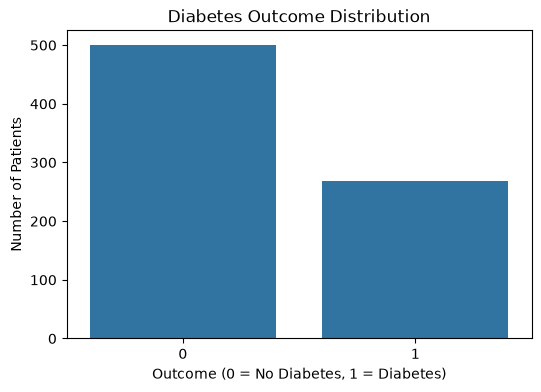

In [16]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Outcome")

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.show()

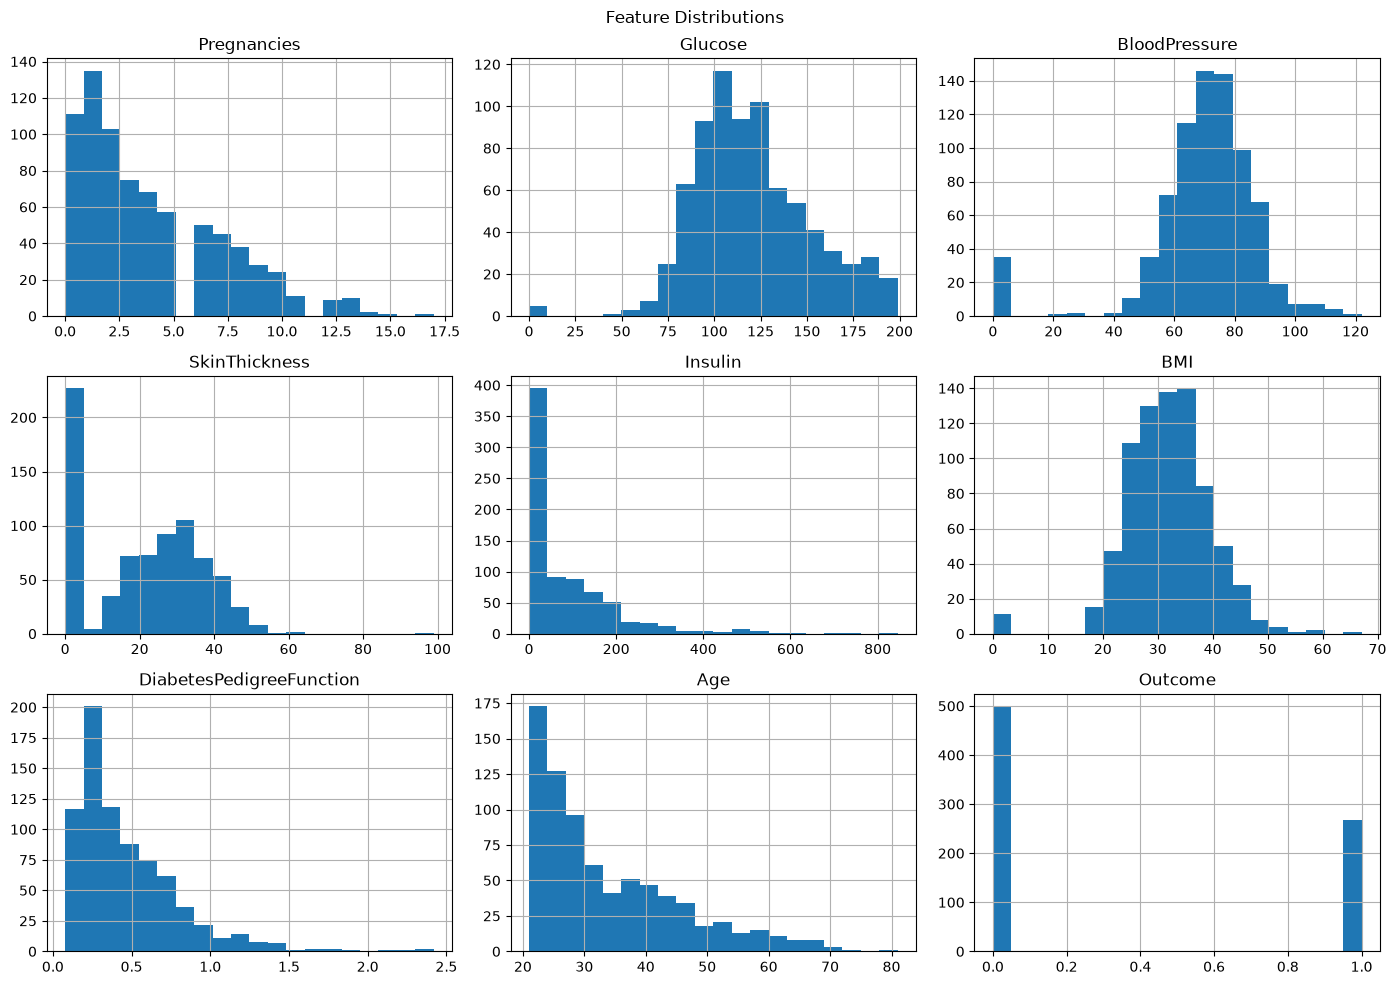

In [17]:
df.hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

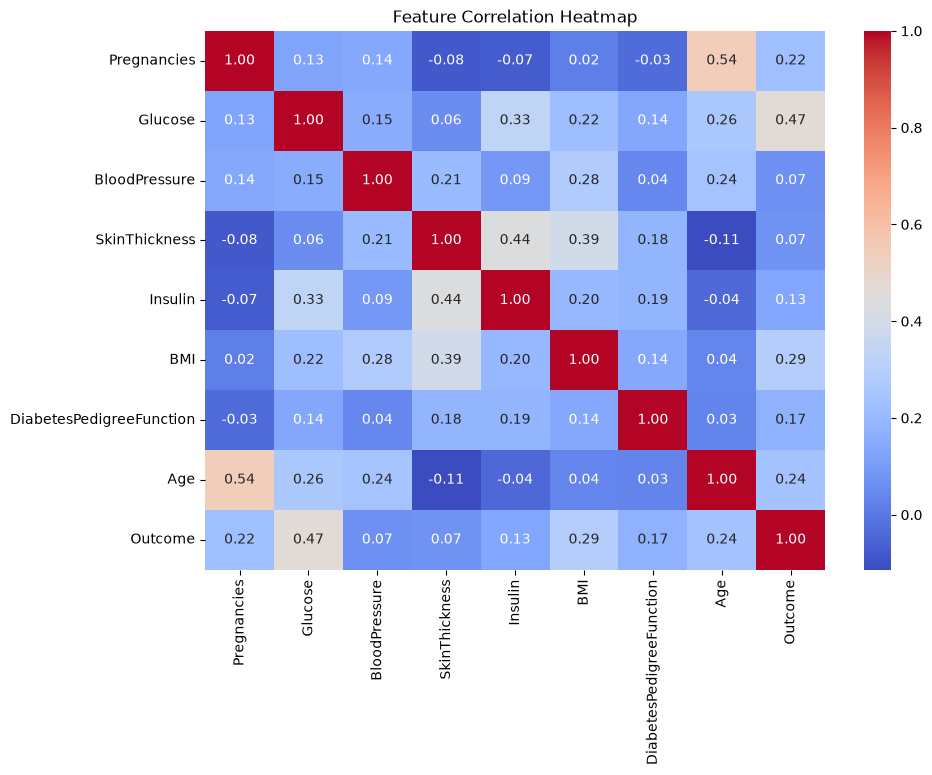

In [18]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

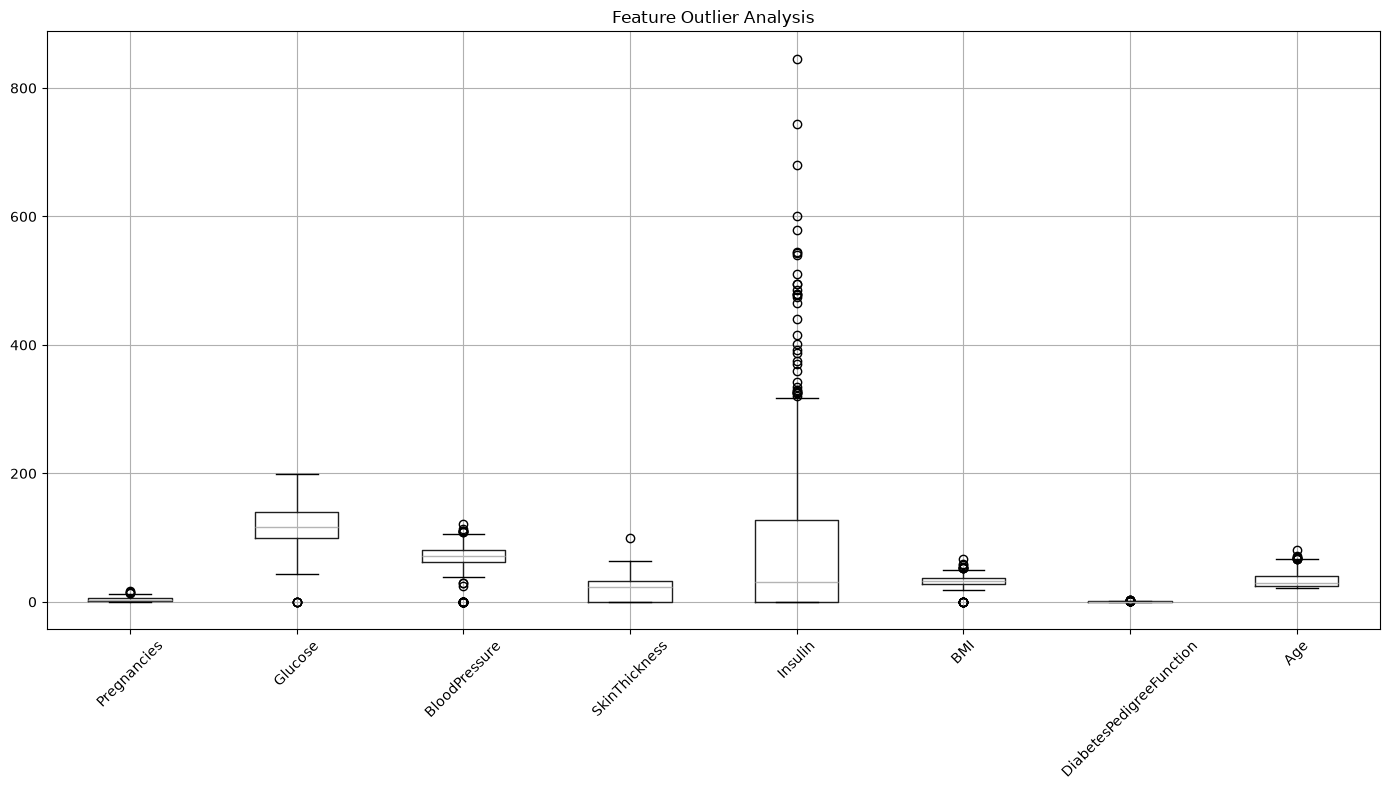

In [19]:
plt.figure(figsize=(14, 8))

df.drop(columns="Outcome").boxplot()

plt.title("Feature Outlier Analysis")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

#### EDA Findings

- The dataset contains 768 patient records and 8 predictive features.
- No explicit NaN values are present in the dataset.
- Several clinical variables contain zero values that are physiologically implausible and require treatment as missing values.
- The target variable contains two classes: diabetic and non-diabetic.
- Feature distributions show variation in clinical measurements and the presence of potential outliers.
- Glucose shows a noticeable relationship with the diabetes outcome.
- Correlation analysis helps identify relationships among the clinical features and target variable.

#### 2. Data Preprocessing

The preprocessing stage prepares the clinical features for machine learning by handling invalid values, separating the target variable, splitting the dataset, and applying feature scaling without introducing data leakage.

In [20]:
df_processed = df.copy()

In [21]:
invalid_zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df_processed[invalid_zero_columns] = (
    df_processed[invalid_zero_columns]
    .replace(0, np.nan)
)

In [22]:
df_processed.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [23]:
for column in invalid_zero_columns:
    df_processed[column] = df_processed[column].fillna(
        df_processed[column].median()
    )

In [24]:
df_processed.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [25]:
X = df_processed.drop("Outcome", axis=1)
y = df_processed["Outcome"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (768, 8)
Target: (768,)


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [27]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 614
Testing samples: 154

Training target distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing target distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

In [30]:
X_train_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,-0.851355,-1.056427,-0.826740,-1.918187,-1.203361,-0.769477,0.310794,-0.792169
711,0.356576,0.144399,0.477772,-0.229874,-1.470195,-0.417498,-0.116439,0.561034
373,-0.549372,-0.556083,-1.152868,1.233330,-0.555335,0.359790,-0.764862,-0.707594
46,-0.851355,0.811525,-1.315932,-0.004766,-0.161437,-0.402832,0.262314,-0.369293
682,-1.153338,-0.889646,-0.663676,1.120776,-0.415565,1.782373,-0.337630,-0.961320


In [31]:
X_train_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,614.0,-6.943414e-17,1.000815,-1.153338,-0.851355,-0.247390,0.658558,3.980368
Glucose,614.0,-1.099374e-16,1.000815,-2.190541,-0.756221,-0.155808,0.611387,2.579408
BloodPressure,614.0,3.095606e-16,1.000815,-3.924957,-0.663676,-0.011420,0.640836,4.065181
SkinThickness,614.0,-3.471707e-17,1.000815,-2.480958,-0.454983,-0.004766,0.332896,7.874025
Insulin,614.0,-4.339634e-18,1.000815,-1.559139,-0.224969,-0.161437,-0.097905,7.703814
BMI,614.0,-1.148556e-15,1.000815,-2.089399,-0.707147,-0.021521,0.594443,5.082179
DiabetesPedigreeFunction,614.0,-1.099374e-16,1.000815,-1.192094,-0.704262,-0.287634,0.490322,5.610293
Age,614.0,-1.084908e-16,1.000815,-1.045895,-0.792169,-0.369293,0.645609,4.028617


In [32]:
print("Missing values in training data:")
print(X_train_scaled.isnull().sum().sum())

print("\nMissing values in test data:")
print(X_test_scaled.isnull().sum().sum())

Missing values in training data:
0

Missing values in test data:
0


#### Preprocessing Summary

- Created a separate copy of the raw dataset to preserve the original data.
- Identified physiologically implausible zero values in selected clinical features.
- Replaced invalid zero values with missing values and applied median imputation.
- Separated the eight clinical features from the target variable.
- Split the dataset into training and testing sets using stratified sampling.
- Applied StandardScaler by fitting only on the training data to prevent data leakage.